In [214]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pce = pd.read_csv("PERSONAL_EXPENDITURE.csv")
saving = pd.read_csv("SAVING_RATE.csv")
credit = pd.read_csv("CREDIT_OWNED.csv")




In [215]:
for df_ in [pce, saving, credit]:
    df_["observation_date"] = pd.to_datetime(df_["observation_date"])
    df_.set_index("observation_date", inplace=True)
    df_.sort_index(inplace=True)


In [216]:
pce = pce.rename(columns={"PCEC96": "consumer_spending"})
saving = saving.rename(columns={"PSAVERT": "saving_rate"})
credit = credit.rename(columns={"TOTALSL": "credit_total"})
df = pce.join(saving, how="inner").join(credit, how="inner")
display(df.head)

<bound method NDFrame.head of                   consumer_spending  saving_rate  credit_total
observation_date                                              
2007-01-01                  11181.0          2.4    2457945.58
2007-02-01                  11178.2          2.8    2470049.92
2007-03-01                  11190.7          3.0    2484433.18
2007-04-01                  11201.5          3.0    2493729.77
2007-05-01                  11218.0          2.8    2510016.06
...                             ...          ...           ...
2025-07-01                  16547.5          4.3    5057212.70
2025-08-01                  16595.8          4.1    5059896.38
2025-09-01                  16614.3          4.0    5071365.99
2025-10-01                  16665.1          3.7    5080601.87
2025-11-01                  16715.4          3.5    5084831.24

[227 rows x 3 columns]>

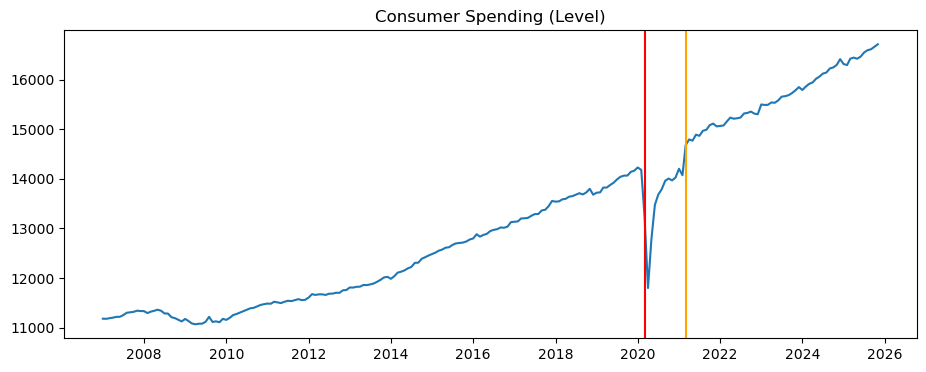

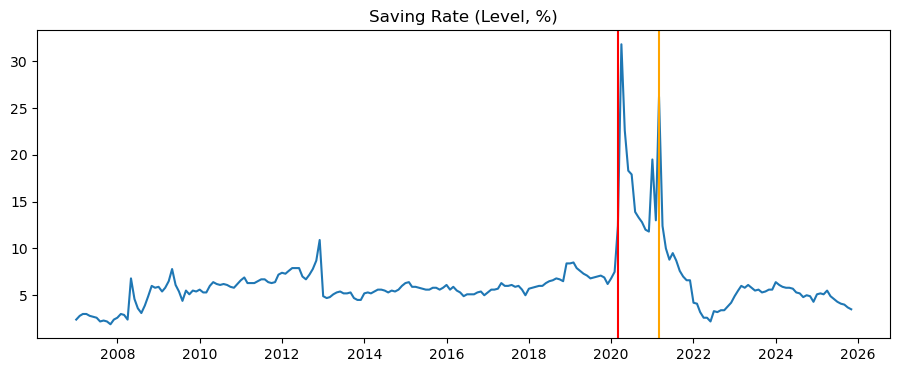

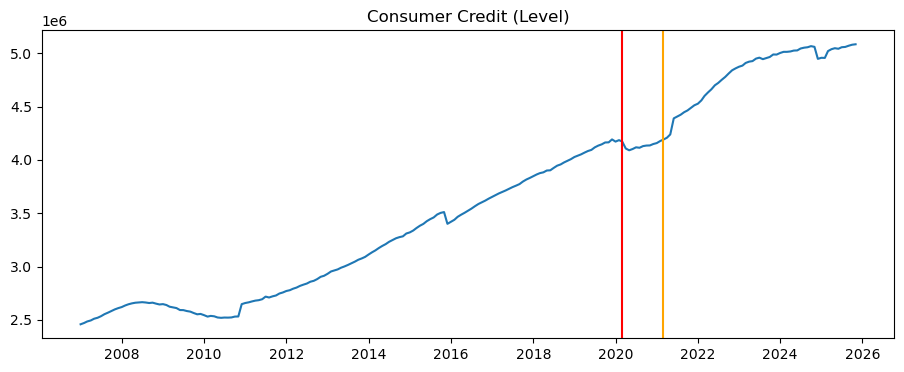

In [217]:
# df["t"] = np.arange(len(df))

# # month seasonality dummies (captures repeating annual patterns)
# df["month"] = df.index.month
# month_dummies = pd.get_dummies(df["month"], prefix="m", drop_first=True)
# df = pd.concat([df.drop(columns=["month"]), month_dummies], axis=1)
# print(df)
# Key dates (for plots + splitting train/test)
covid_start = pd.Timestamp("2020-03-01")
inflation_start = pd.Timestamp("2021-03-01")


def plot_series(col, title=None):
    plt.figure(figsize=(11, 4))
    plt.plot(df.index, df[col])
    plt.axvline(covid_start, color="red")
    plt.axvline(inflation_start, color="orange")
    plt.title(title or col)
    plt.show()

# Levels
plot_series("consumer_spending", "Consumer Spending (Level)")
plot_series("saving_rate", "Saving Rate (Level, %)")
plot_series("credit_total", "Consumer Credit (Level)")

MSE:  962763.97
RMSE: 981.21
MAE:  897.63
R2:   0.018


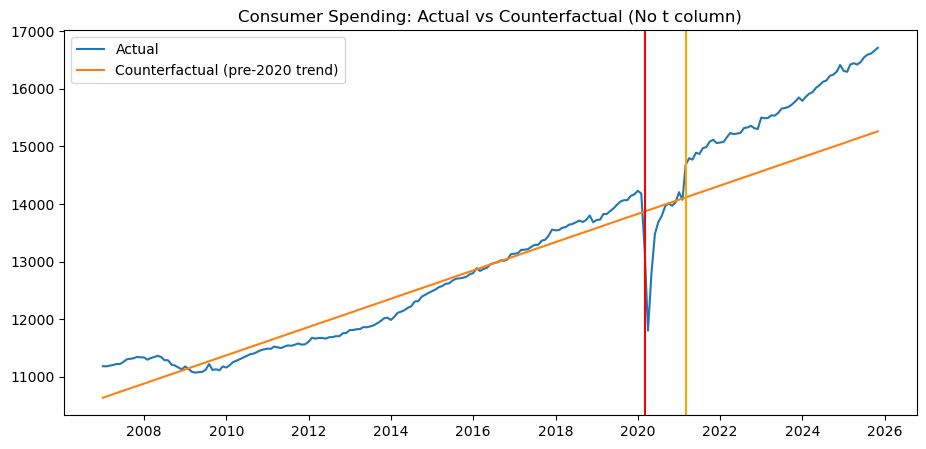

In [218]:
train = df[df.index < covid_start].copy()
test  = df[df.index >= covid_start].copy()

# Create numeric time feature from dates (months since start)
start_date = df.index.min()
time_months_all = ((df.index.year - start_date.year) * 12 + (df.index.month - start_date.month)).to_numpy().reshape(-1, 1)
# print(time_months_all)
# # Same feature but for train only
time_months_train = time_months_all[df.index < covid_start]

# Fit model on pre-COVID spending trend
model = LinearRegression()
model.fit(time_months_train, train["consumer_spending"])
df["spending_pred"] = model.predict(time_months_all)

y_pred = df.loc[test.index, "spending_pred"] 

# Predict counterfactual for entire timeline

mse  = mean_squared_error(test["consumer_spending"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["consumer_spending"], y_pred)
r2   = r2_score(test["consumer_spending"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")
# Plot actual vs counterfactual
plt.figure(figsize=(11, 5))
plt.plot(df.index, df["consumer_spending"], label="Actual")
plt.plot(df.index, df["spending_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Consumer Spending: Actual vs Counterfactual (No t column)")
plt.show()

Consumer Spending (Real PCE)

To evaluate whether consumer spending changed after COVID and the inflation shock, a counterfactual linear regression model was trained using pre-2020 data to estimate the expected spending trajectory. When this model was applied to the post-2020 period, it produced a very low coefficient of determination (R² ≈ 0.018), meaning that the historical trend explains only about 1.8% of the variation in post-COVID spending. In addition, the prediction errors were relatively large (RMSE ≈ 981 and MAE ≈ 898), indicating that the model’s forecasts deviated substantially from actual observed spending. These metrics show that post-COVID spending no longer follows its historical trajectory, suggesting a structural change in consumption behavior. Although overall spending remained relatively strong, it behaved differently from what pre-pandemic trends would predict.

MSE:  34.11
RMSE: 5.84
MAE:  4.18
R2:   -0.078


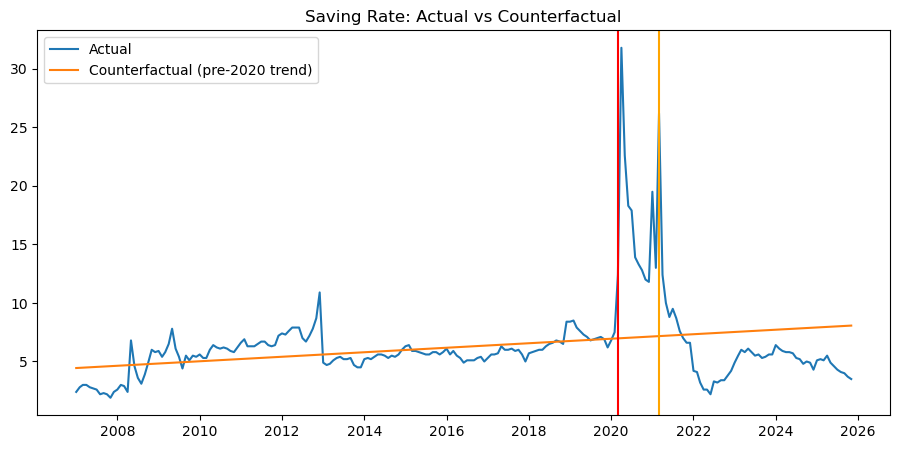

In [221]:
saving_model = LinearRegression()
saving_model.fit(time_months_train, train["saving_rate"])

df["saving_pred"] = saving_model.predict(time_months_all)
y_pred = df.loc[test.index, "saving_pred"] 



mse  = mean_squared_error(test["saving_rate"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["saving_rate"], y_pred)
r2   = r2_score(test["saving_rate"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")

plt.figure(figsize=(11, 5))
plt.plot(df.index, df["saving_rate"], label="Actual")
plt.plot(df.index, df["saving_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Saving Rate: Actual vs Counterfactual")
plt.show()

Personal Saving Rate

The saving rate model reveals an even stronger structural break. A counterfactual model trained on pre-2020 data performs worse than a simple average prediction in the post-COVID period, as indicated by a negative R² value. A negative R² means that the historical trend fails to explain current behavior entirely. The model also produces sizable prediction errors (RMSE ≈ 5.84 and MAE ≈ 4.18), indicating that actual saving rates deviated meaningfully from expected values. This divergence reflects the unusual economic environment: savings surged during the pandemic due to stimulus payments and limited spending opportunities, then fell sharply as inflation eroded purchasing power. The poor model performance confirms that saving behavior experienced a major structural shift.

MSE:  81128976281.97
RMSE: 284831.49
MAE:  246559.97
R2:   0.338


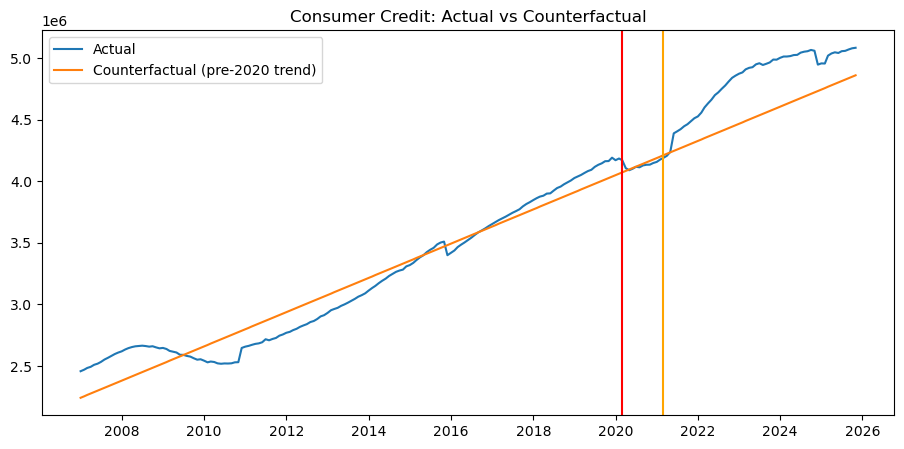

In [222]:

credit_model = LinearRegression()
credit_model.fit(time_months_train, train["credit_total"])

df["credit_pred"] = credit_model.predict(time_months_all)
y_pred = df.loc[test.index, "credit_pred"] 


mse  = mean_squared_error(test["credit_total"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["credit_total"], y_pred)
r2   = r2_score(test["credit_total"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")

plt.figure(figsize=(11, 5))
plt.plot(df.index, df["credit_total"], label="Actual")
plt.plot(df.index, df["credit_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Consumer Credit: Actual vs Counterfactual")
plt.show()


Consumer Credit Outstanding

Consumer credit shows a different pattern compared to spending and saving. The counterfactual model trained on pre-COVID data achieves a moderate explanatory power (R² ≈ 0.338), meaning that about 33.8% of the variation in post-COVID credit levels can still be explained by historical trends. While prediction errors exist (RMSE ≈ 284,831 and MAE ≈ 246,559), the model performs substantially better than in the spending and saving cases. This suggests that borrowing behavior continued along a partially predictable upward trajectory even after the inflation shock. The continued growth of credit, despite rising interest rates, implies that households increasingly relied on borrowing to maintain consumption as savings declined.

Using a counterfactual model trained only on pre-March 2020 data, we compared observed post-inflation behavior to what would have been expected had historical trends continued unchanged. The results suggest a meaningful structural shift in household financial behavior. Real consumer spending recovered and remains modestly above its pre-COVID trend, indicating that aggregate consumption did not collapse permanently. However, the personal saving rate has remained significantly below its historical trajectory, suggesting households are saving structurally less than expected. At the same time, consumer credit levels are persistently above their pre-2020 trend, indicating increased reliance on borrowing. Taken together, these patterns imply that while spending itself returned toward trend, the way households finance consumption has shifted—characterized by lower savings buffers and higher credit usage—pointing to a lasting behavioral adjustment rather than a purely temporary disruption.